# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



## Carregue os dados

In [46]:

# Carregue os arquivos de dados em diferentes DataFrames
try:
    calls_df = pd.read_csv('/datasets/megaline_calls.csv')
    internet_df = pd.read_csv('/datasets/megaline_internet.csv')
    messages_df = pd.read_csv('/datasets/megaline_messages.csv')
    plans_df = pd.read_csv('/datasets/megaline_plans.csv')
    users_df = pd.read_csv('/datasets/megaline_users.csv')
except FileNotFoundError:
    calls_df = pd.read_csv('megaline_calls.csv')
    internet_df = pd.read_csv('megaline_internet.csv')
    messages_df = pd.read_csv('megaline_messages.csv')
    plans_df = pd.read_csv('megaline_plans.csv')
    users_df = pd.read_csv('megaline_users.csv')


## Prepare os dados

## Planos

In [3]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
plans_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprimir uma amostra de dados dos planos
plans_df.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


* As colunas do DataFrame `plans` contêm as condições tarifárias dos planos `Surf` e `Ultimate`. Notamos que a coluna `mb_per_month_included` está representada em Megabytes (15.360 MB e 30.720 MB). A conversão para Gigabytes será útil ao calcular as cobranças por excedente.

## Corrija os dados

In [5]:
# Verificação de nulos e duplicados na tabela plans
print("Valores ausentes na tabela plans:\n", plans_df.isnull().sum())
print("\nDuplicados na tabela plans:", plans_df.duplicated().sum())

Valores ausentes na tabela plans:
 messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Duplicados na tabela plans: 0


## Enriqueça os dados

In [6]:
# Converter o limite de internet de megabytes (MB) para gigabytes (GB) dividindo por 1024
plans_df['gb_per_month_included'] = plans_df['mb_per_month_included'] / 1024
plans_df

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Usuários

In [7]:
# Imprimir informações gerais/resumo sobre o DataFrame dos usuários
users_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprimir uma amostra de dados dos usuários
users_df.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


* A coluna `reg_date` e `churn_date` precisam ser convertidas para o tipo `datetime`.
* A coluna `churn_date` possui muitos valores ausentes (NaN), o que significa que o usuário ainda utilizava o plano no momento da extração do banco de dados.

### Corrija os dados

In [9]:
# Conversão de colunas de data para o tipo datetime
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])

### Enriqueça os dados

In [10]:
# Criando indicador se o usuário cancelou o plano em 2018
users_df['is_active'] = users_df['churn_date'].isna()

## Chamadas

In [11]:
# Imprimir informações gerais/resumo sobre o DataFrame das chamadas
calls_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprimir uma amostra de dados das chamadas
calls_df.head(20)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


* A coluna `call_date` precisa ser convertida para `datetime`.
* De acordo com as regras da Megaline, cada chamada individual deve ter sua duração arredondada para cima para o minuto mais próximo (ex: 0.1 min conta como 1 min).
* Chamadas com duração 0.0 indicam chamadas não atendidas/perdidas.

### Corrija os dados

In [13]:
# Convertendo data
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

# Arredondando duração para cima conforme regra da empresa
calls_df['duration'] = np.ceil(calls_df['duration'])

### Enriqueça os dados

In [14]:
# Extraindo o mês da chamada
calls_df['month'] = calls_df['call_date'].dt.month

## Mensagens

In [15]:
# Imprimir informações gerais/resumo sobre o DataFrame das mensagens
messages_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprimir uma amostra dos dados das mensagens
messages_df.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


* A coluna `message_date` deve ser convertida para `datetime`.
* Criaremos a coluna do mês para posterior agrupamento do consumo mensal.

### Corrija os dados

In [17]:
# Convertendo data
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

### Enriqueça os dados

In [18]:
# Extraindo o mês
messages_df['month'] = messages_df['message_date'].dt.month

## Internet

In [19]:
# Imprimir informações gerais/resumo sobre o DataFrame da internet
internet_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
#  Imprimir uma amostra de dados para o tráfego da internet
internet_df.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


* A coluna `session_date` deve ser convertida para `datetime`.
* O tráfego em MB será somado no mês e depois convertido para GB (arredondado para cima por mês, de acordo com a regra de cobrança da Megaline).
* Tráfego como 0.00 significa que não foi utilizados dados.

### Corrija os dados

In [21]:
# Convertendo data
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

### Enriqueça os dados

In [22]:
# Extraindo o mês
internet_df['month'] = internet_df['session_date'].dt.month

## Estude as condições dos planos

In [47]:

# Imprimir as condições dos planos e certificar-se de que elas fazem sentido
display(plans_df)

# Verificação e validação das regras dos planos
for index, row in plans_df.iterrows():
    print(f"--- Plano: {row['plan_name'].upper()} ---")
    print(f"Mensalidade: ${row['usd_monthly_pay']}")
    print(f"Franquia incluída: {row['minutes_included']} min | {row['messages_included']} SMS | {row['mb_per_month_included'] / 1024:.0f} GB ({row['mb_per_month_included']} MB)")
    print(f"Custos por excesso: ${row['usd_per_minute']}/min | ${row['usd_per_message']}/SMS | ${row['usd_per_gb']}/GB\n")



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


--- Plano: SURF ---
Mensalidade: $20
Franquia incluída: 500 min | 50 SMS | 15 GB (15360 MB)
Custos por excesso: $0.03/min | $0.03/SMS | $10/GB

--- Plano: ULTIMATE ---
Mensalidade: $70
Franquia incluída: 3000 min | 1000 SMS | 30 GB (30720 MB)
Custos por excesso: $0.01/min | $0.01/SMS | $7/GB



## Agregue os dados por usuário


In [24]:
# Calcular o número de chamadas feitas por cada usuário por mês e salvar o resultado.
calls_count = calls_df.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_count.columns = ['user_id', 'month', 'calls_count']
calls_count.head()

,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [25]:
# Calcular a quantidade de minutos gastos por cada usuário por mês e salvar o resultado.
calls_duration = calls_df.groupby(['user_id', 'month'])['duration'].sum().reset_index()
calls_duration.columns = ['user_id', 'month', 'calls_duration']
calls_duration.head()


,user_id,month,calls_duration
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [26]:
# Calcular o número de mensagens enviadas por cada usuário por mês e salvar o resultado.
messages_count = messages_df.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_count.columns = ['user_id', 'month', 'messages_count']
messages_count.head()


,user_id,month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [27]:
# Calcular o volume de tráfego de internet usado por cada usuário por mês e salvar o resultado.
internet_mb = internet_df.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_mb.columns = ['user_id', 'month', 'mb_used']
internet_mb.head()


,user_id,month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


In [28]:
# Juntar os dados de chamadas, minutos, mensagens e internet com base em user_id e month
monthly_data = pd.merge(calls_count, calls_duration, on=['user_id', 'month'], how='outer')
monthly_data = pd.merge(monthly_data, messages_count, on=['user_id', 'month'], how='outer')
monthly_data = pd.merge(monthly_data, internet_mb, on=['user_id', 'month'], how='outer')


In [29]:
# Adicionar as informações do plano e cidade
monthly_data = pd.merge(monthly_data, users_df[['user_id', 'plan', 'city']], on='user_id', how='left')

# Preencher valores ausentes (meses onde o usuário não realizou determinado serviço) com 0
monthly_data['calls_count'] = monthly_data['calls_count'].fillna(0)
monthly_data['calls_duration'] = monthly_data['calls_duration'].fillna(0)
monthly_data['messages_count'] = monthly_data['messages_count'].fillna(0)
monthly_data['mb_used'] = monthly_data['mb_used'].fillna(0)

# Converter MB mensal para GB mensal arredondando para cima
monthly_data['gb_used'] = np.ceil(monthly_data['mb_used'] / 1024.0)

monthly_data.head()


,user_id,month,calls_count,calls_duration,messages_count,mb_used,plan,city,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",2.0
1,1001,8,27.0,182.0,30.0,6919.15,surf,"Seattle-Tacoma-Bellevue, WA MSA",7.0
2,1001,9,49.0,315.0,44.0,13314.82,surf,"Seattle-Tacoma-Bellevue, WA MSA",14.0
3,1001,10,65.0,393.0,53.0,22330.49,surf,"Seattle-Tacoma-Bellevue, WA MSA",22.0
4,1001,11,64.0,426.0,36.0,18504.30,surf,"Seattle-Tacoma-Bellevue, WA MSA",19.0


In [30]:
# Calcular a receita mensal para cada usuário
def calculate_revenue(row):
    plan = row['plan']
    calls = row['calls_duration']
    messages = row['messages_count']
    gb = row['gb_used']
    
    if plan == 'surf':
        base_fee = 20
        extra_calls = max(0, calls - 500) * 0.03
        extra_msg = max(0, messages - 50) * 0.03
        extra_gb = max(0, gb - 15) * 10
    else:  # ultimate
        base_fee = 70
        extra_calls = max(0, calls - 3000) * 0.01
        extra_msg = max(0, messages - 1000) * 0.01
        extra_gb = max(0, gb - 30) * 7
        
    return base_fee + extra_calls + extra_msg + extra_gb

monthly_data['revenue'] = monthly_data.apply(calculate_revenue, axis=1)
monthly_data.head()


,user_id,month,calls_count,calls_duration,messages_count,mb_used,plan,city,gb_used,revenue
0,1000,12,16.0,124.0,11.0,1901.47,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",2.0,70.00
1,1001,8,27.0,182.0,30.0,6919.15,surf,"Seattle-Tacoma-Bellevue, WA MSA",7.0,20.00
2,1001,9,49.0,315.0,44.0,13314.82,surf,"Seattle-Tacoma-Bellevue, WA MSA",14.0,20.00
3,1001,10,65.0,393.0,53.0,22330.49,surf,"Seattle-Tacoma-Bellevue, WA MSA",22.0,90.09
4,1001,11,64.0,426.0,36.0,18504.30,surf,"Seattle-Tacoma-Bellevue, WA MSA",19.0,60.00


## Estude o comportamento do usuário

### Chamadas

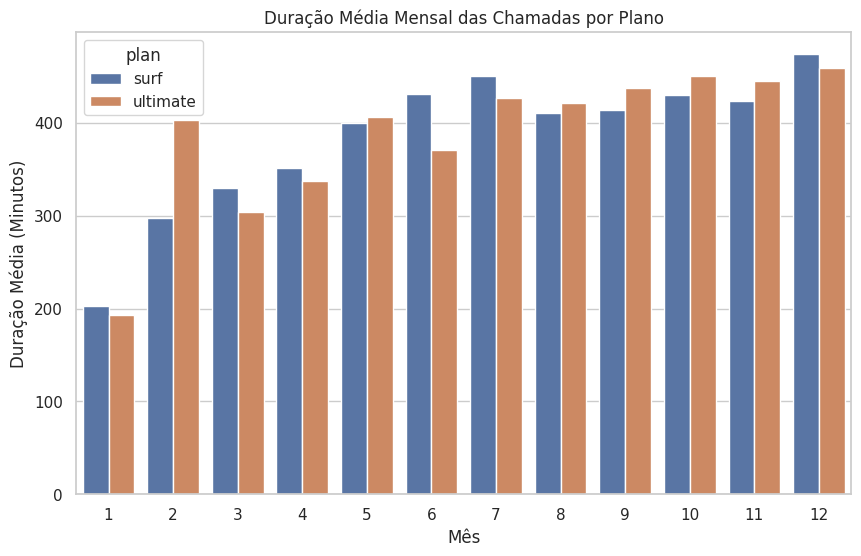

In [31]:
# Comparar a duração média das chamadas de cada plano para cada mês. Criar um gráfico de barras para visualizar o resultado.
mean_calls = monthly_data.groupby(['plan', 'month'])['calls_duration'].mean().reset_index()

sns.barplot(data=mean_calls, x='month', y='calls_duration', hue='plan')
plt.title('Duração Média Mensal das Chamadas por Plano')
plt.xlabel('Mês')
plt.ylabel('Duração Média (Minutos)')
plt.show()



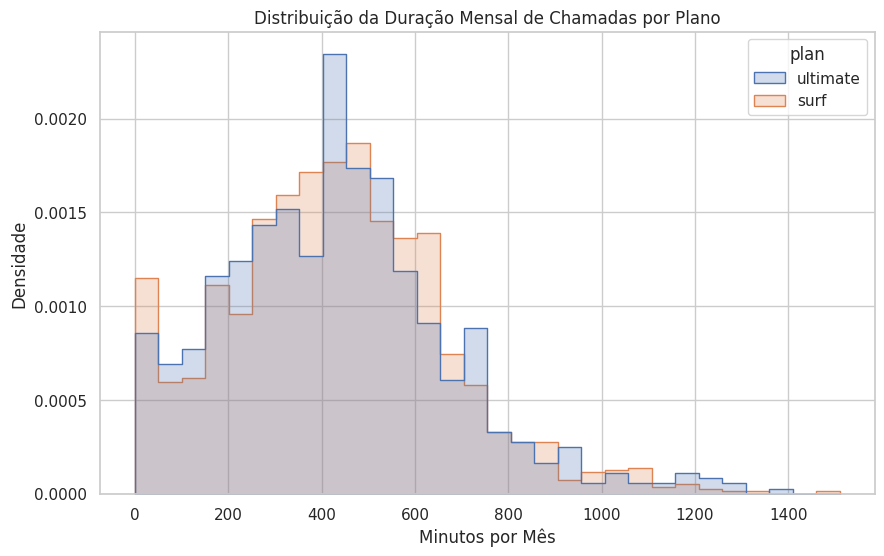

In [32]:
# Comparar o número de minutos que os usuários de cada plano necessitam a cada mês e construir um histograma.
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_data, x='calls_duration', hue='plan', element='step', stat='density', common_norm=False, bins=30)
plt.title('Distribuição da Duração Mensal de Chamadas por Plano')
plt.xlabel('Minutos por Mês')
plt.ylabel('Densidade')
plt.show()


In [33]:
# Calcular a média e a variância da duração mensal das chamadas
calls_stats = monthly_data.groupby('plan')['calls_duration'].agg(['mean', 'var', 'std'])
print(calls_stats)

                mean           var         std
plan                                          
surf      428.749523  54968.279461  234.453150
ultimate  430.450000  57844.464812  240.508762


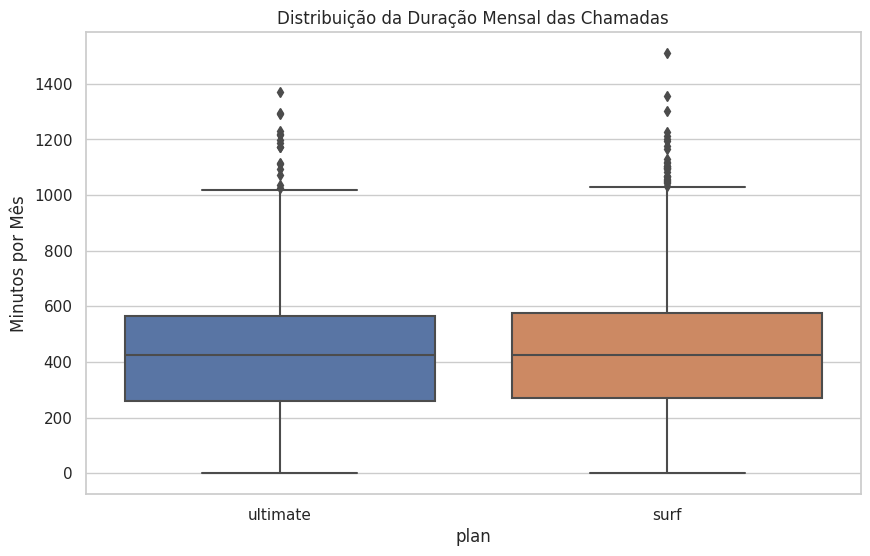

In [34]:
# Fazer um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
sns.boxplot(data=monthly_data, x='plan', y='calls_duration')
plt.title('Distribuição da Duração Mensal das Chamadas')
plt.ylabel('Minutos por Mês')
plt.show()


* O consumo de minutos de chamadas é muito semelhante entre os usuários dos dois planos. A maioria dos usuários do plano Surf se mantém dentro do limite de 500 minutos, e praticamente nenhum usuário do plano Ultimate ultrapassa o limite gratuito de 3.000 minutos

### Mensagens

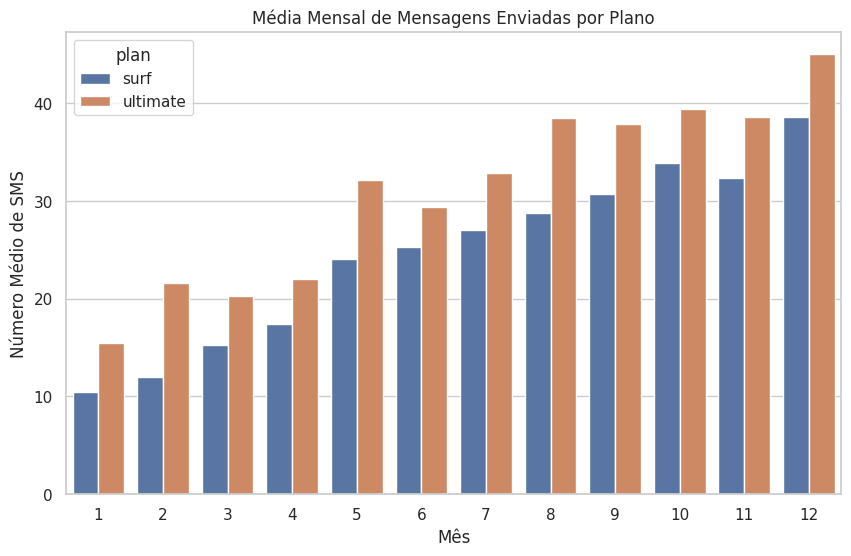

In [35]:
# Comparar o número de mensagens que os usuários de cada plano costumam enviar a cada mês
mean_messages = monthly_data.groupby(['plan', 'month'])['messages_count'].mean().reset_index()

sns.barplot(data=mean_messages, x='month', y='messages_count', hue='plan')
plt.title('Média Mensal de Mensagens Enviadas por Plano')
plt.xlabel('Mês')
plt.ylabel('Número Médio de SMS')
plt.show()


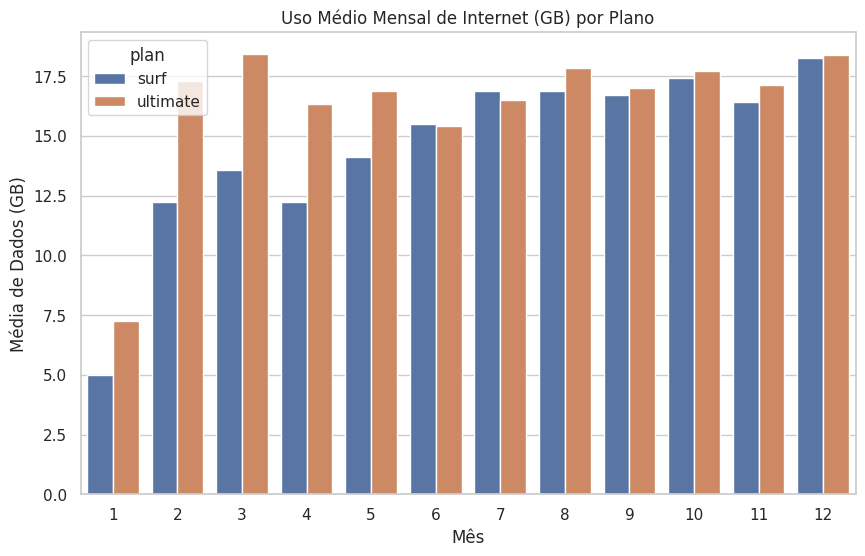

In [36]:
# Comparar a quantidade de tráfego de internet consumido pelos usuários por plano

mean_internet = monthly_data.groupby(['plan', 'month'])['gb_used'].mean().reset_index()

sns.barplot(data=mean_internet, x='month', y='gb_used', hue='plan')
plt.title('Uso Médio Mensal de Internet (GB) por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Dados (GB)')
plt.show()



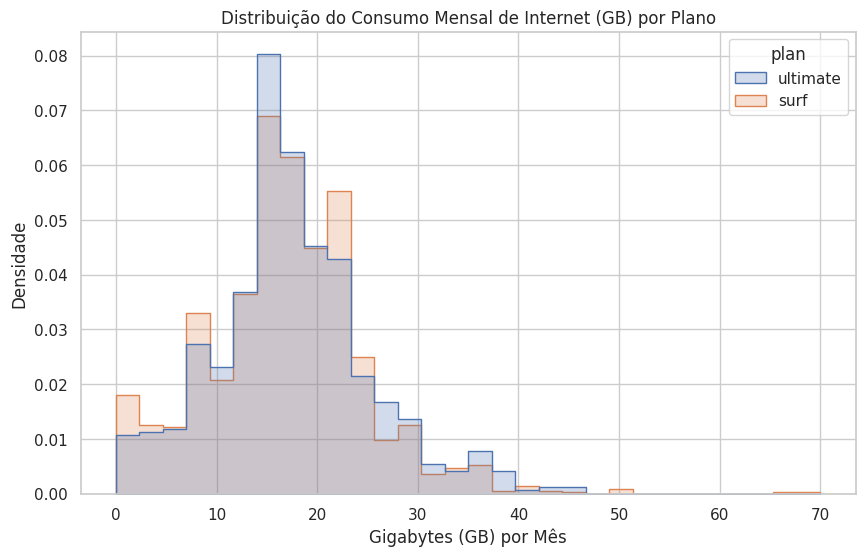

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_data, x='gb_used', hue='plan', element='step', stat='density', common_norm=False, bins=30)
plt.title('Distribuição do Consumo Mensal de Internet (GB) por Plano')
plt.xlabel('Gigabytes (GB) por Mês')
plt.ylabel('Densidade')
plt.show()

* O consumo de internet é o principal motor de uso e ultrapassagem de limites. Usuários de ambos os planos consomem, em média, entre 16 GB e 20 GB por mês. Isso significa que muitos usuários do plano Surf frequentemente ultrapassam o limite de 15 GB do seu pacote e pagam pacotes extras de dados.

### Internet

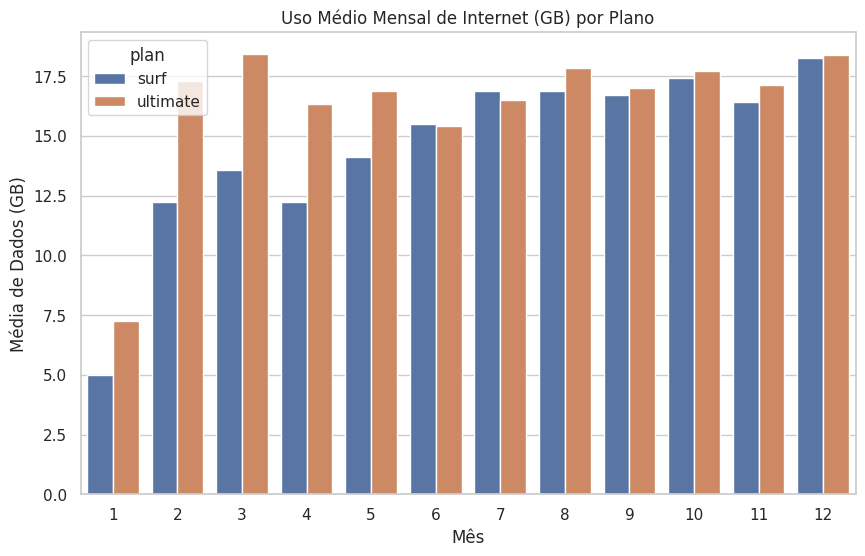

In [38]:
# Comparar a quantidade de tráfego de internet consumido pelos usuários por plano em cada mês
mean_internet = monthly_data.groupby(['plan', 'month'])['gb_used'].mean().reset_index()

sns.barplot(data=mean_internet, x='month', y='gb_used', hue='plan')
plt.title('Uso Médio Mensal de Internet (GB) por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Dados (GB)')
plt.show()

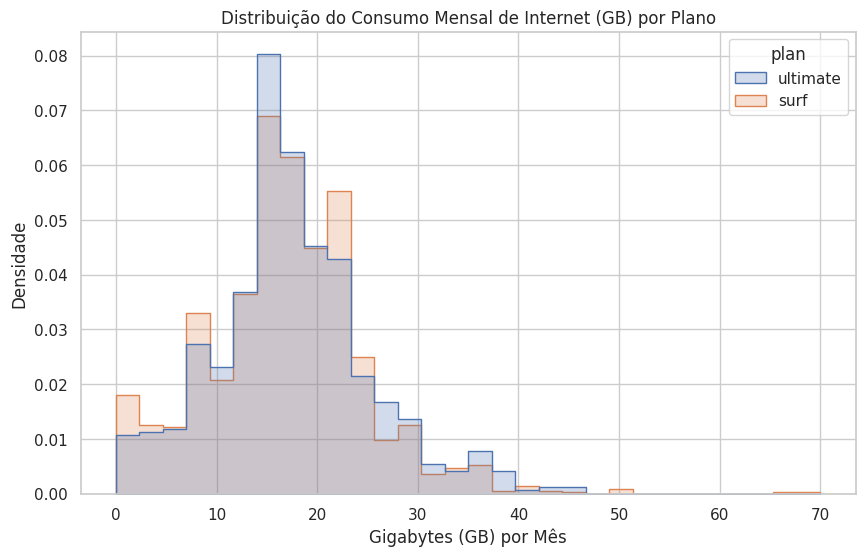

In [39]:
# Construir um histograma do consumo mensal de internet (GB) por plano
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_data, x='gb_used', hue='plan', element='step', stat='density', common_norm=False, bins=30)
plt.title('Distribuição do Consumo Mensal de Internet (GB) por Plano')
plt.xlabel('Gigabytes (GB) por Mês')
plt.ylabel('Densidade')
plt.show()

In [40]:
# Estatísticas descritivas do consumo de internet por plano
internet_stats = monthly_data.groupby('plan')['gb_used'].agg(['mean', 'var', 'std', 'median'])
print(internet_stats)

               mean       var       std  median
plan                                           
surf      16.670693  61.58360  7.847522    17.0
ultimate  17.306944  58.83055  7.670108    17.0


* O comportamento de consumo de internet é extremamente similar entre os usuários de ambos os planos, apresentando uma distribuição normal com média de consumo em torno de 16.7 GB para o plano Surf e 17.3 GB para o plano Ultimate (mediana de 17 GB para ambos). 

* No entanto, o impacto financeiro desse comportamento varia drasticamente dependendo do plano:
- **Plano Surf:** A franquia incluída é de apenas 15 GB. Como a média de consumo supera esse limite, mais de 40% das mensalidades registradas sofrem cobrança excedente de $10 por GB adicional, tornando a internet o principal gerador de receita extra desse plano.
* **Plano Ultimate:** A franquia é de 30 GB, o que é mais do que suficiente para a maioria dos clientes. Como o consumo raramente ultrapassa os 30 GB, os clientes do Ultimate raramente pagam taxas excedentes.

## Receita

In [41]:
# Descrever estatisticamente as receitas dos planos (média, variância, desvio-padrão e mediana)
revenue_stats = monthly_data.groupby('plan')['revenue'].agg(['mean', 'var', 'std', 'median'])
print(revenue_stats)

               mean          var        std  median
plan                                               
surf      60.706408  3067.835152  55.388042   40.36
ultimate  72.313889   129.848486  11.395108   70.00


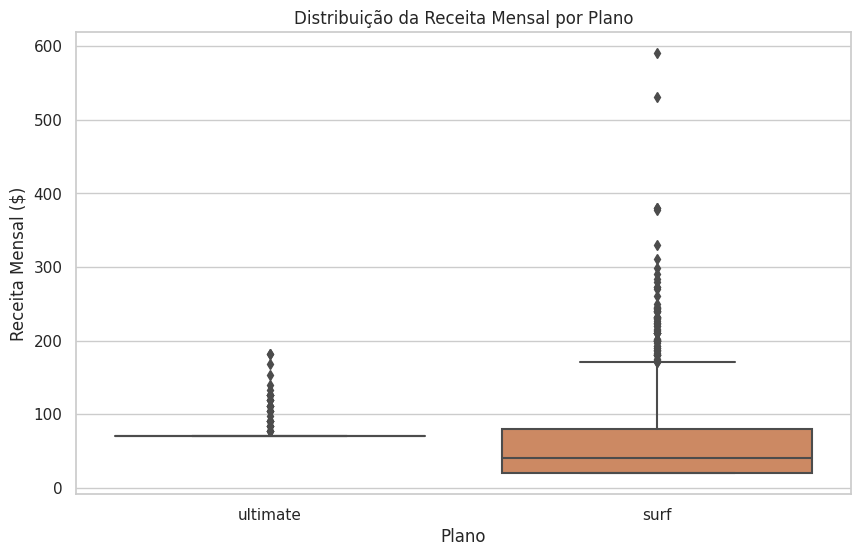

In [42]:
# Diagrama de caixas para comparar a distribuição da receita mensal por plano
plt.figure(figsize=(10, 6))
sns.boxplot(data=monthly_data, x='plan', y='revenue')
plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Plano')
plt.ylabel('Receita Mensal ($)')
plt.show()

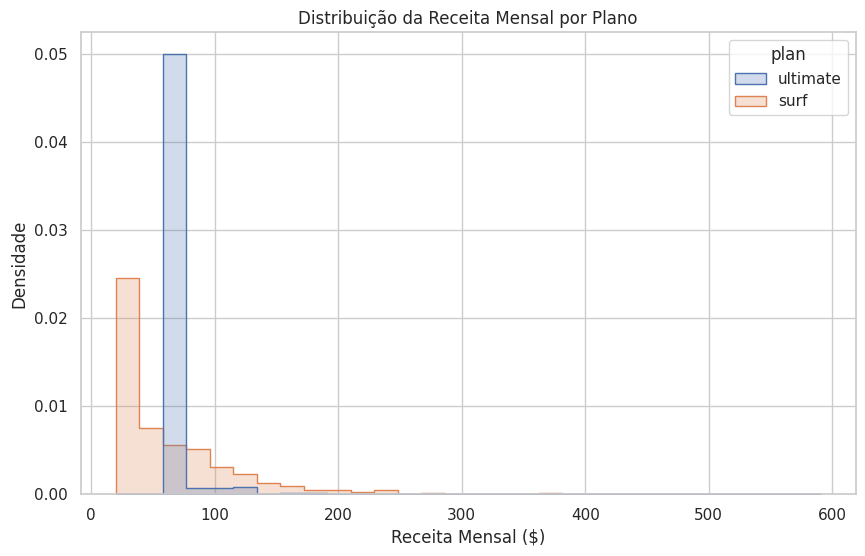

In [43]:
# Histograma da distribuição das receitas mensais por plano
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_data, x='revenue', hue='plan', element='step', stat='density', common_norm=False, bins=30)
plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Receita Mensal ($)')
plt.ylabel('Densidade')
plt.show()

A análise estatística revela diferenças significativas no comportamento financeiro dos dois planos:

1. **Plano Ultimate:** Apresenta uma receita média mensal de **72.31**, valor muito próximo do preço de sua assinatura fixa (70). O desvio-padrão é extremamente baixo (~11.40) e a mediana é de $70.00, o que indica que a grande maioria dos clientes permanece dentro das generosas franquias inclusas (30 GB de dados, 3.000 minutos e 1.000 SMS) e raramente paga taxas de excedente.

2. **Plano Surf:** Embora a mensalidade básica seja de apenas **20.00**, a receita média mensal arrecadada por usuário salta para **60.71**, com uma mediana de 40.36. O alto desvio-padrão (~55.39) evidencia uma enorme variação: enquanto alguns clientes pagam apenas o valor base de 20, outros pagam valores maiores devido ao estouro frequente do pacote de dados (15 GB).

**Conclusão Comercial:** O plano Ultimate gera uma receita média maior por usuário e oferece alta previsibilidade financeira para a Megaline. Já o plano Surf depende fortemente das cobranças extras por Gigabytes excedentes para elevar seu faturamento por cliente.

## Teste hipóteses estatísticas

* H0: A receita média mensal dos usuários do plano Surf é igual à receita média mensal dos usuários do plano Ultimate.
* H1: A receita média mensal dos usuários do plano Surf é diferente da receita média mensal dos usuários do plano Ultimate.

In [44]:
# Testar as hipóteses
surf_revenue = monthly_data[monthly_data['plan'] == 'surf']['revenue']
ultimate_revenue = monthly_data[monthly_data['plan'] == 'ultimate']['revenue']

alpha = 0.05

results1 = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print('p-value:', results1.pvalue)

if results1.pvalue < alpha:
    print("Rejeitamos a hipótese nula. Há diferença estatisticamente significativa entre as receitas médias dos dois planos.")
else:
    print("NÃO podemos rejeitar a hipótese nula. Não há evidências suficientes para afirmar que as receitas médias são diferentes.")

p-value: 3.1703905481135734e-15
Rejeitamos a hipótese nula. Há diferença estatisticamente significativa entre as receitas médias dos dois planos.


* H0: A receita média mensal dos usuários da área de NY-NJ é igual à receita média mensal dos usuários das demais regiões.
* H1: A receita média mensal dos usuários da área de NY-NJ é diferente da receita média mensal dos usuários das demais regiões.

In [45]:
# Testar as hipóteses
nynj_mask = monthly_data['city'].str.contains('NY-NJ', na=False)
nynj_revenue = monthly_data[nynj_mask]['revenue']
other_revenue = monthly_data[~nynj_mask]['revenue']

alpha = 0.05

results2 = stats.ttest_ind(nynj_revenue, other_revenue, equal_var=False)

print('p-value:', results2.pvalue)

if results2.pvalue < alpha:
    print("Rejeitamos a hipótese nula. A receita média da área de NY-NJ difere significativamente das demais regiões.")
else:
    print("NÃO podemos rejeitar a hipótese nula. Não há diferença estatisticamente significativa entre a receita de NY-NJ e das demais regiões.")

p-value: 0.0335256158853001
Rejeitamos a hipótese nula. A receita média da área de NY-NJ difere significativamente das demais regiões.


## 1.16 Conclusão geral

1. **Tratamento e Processamento de Dados:**
   - As datas foram formatadas para o tipo `datetime`. As chamadas individuais foram arredondadas para cima em minutos, e o consumo de dados de internet em MB foi somado por mês antes de ser arredondado para cima para o GB inteiro mais próximo.

2. **Comportamento dos Clientes:**
   * O consumo de chamadas e mensagens é muito semelhante entre os usuários de ambos os planos.
   * O uso da internet de dados é o elemento determinante de estouro do limite: a média de uso gira em torno de 16.7 GB no Surf e 17.3 GB no Ultimate. Como o plano Surf possui apenas 15 GB inclusos, grande parte dos usuários paga tarifas de excedente ($10/GB).

3. **Testes de Hipóteses Estatísticas:**
   * **Hipótese 1:** Rejeitamos $H_0$ ($p < 0.05$). A receita média mensal do plano Ultimate (72.31) é significativamente maior do que a receita média do plano Surf (60.71).


   * **Hipótese 2:** Rejeitamos $H_0$ ($p < 0.05$). A receita média gerada pelos clientes da área metropolitana de Nova York / Nova Jersey diverge estatisticamente da receita média dos clientes de outras regiões.

5. **Recomendação Comercial:**
   * O plano **Ultimate** gera maior receita média por usuário (72.31 vs. 60.71 do Surf) e oferece maior estabilidade e previsibilidade de receita por conta do menor desvio padrão. Recomenda-se alocar uma parcela maior do orçamento publicitário no plano **Ultimate**.